In [55]:
from utils.misc import load_module
import yaml
import torch
import os
import pickle
import random
import xarray as xr
import numpy as np
import copy
from sklearn.metrics import mean_squared_error

In [79]:
model_name = "tnpd"

In [80]:
model_cls = getattr(load_module(f'models/{model_name}.py'), model_name.upper())
with open(f'configs/emnist/{model_name}.yaml', 'r') as f:    # Keeping the config file same as the emnist config file
    config = yaml.safe_load(f)

if model_name in ["np", "anp", "cnp", "canp", "bnp", "banp", "tnpd", "tnpa", "tnpnd", "convcnp"]:
    model = model_cls(**config)

In [81]:
ckpt = torch.load(f"results/wustl/{model_name}/default-{model_name}/ckpt.tar", map_location='cuda', weights_only=False)
model.load_state_dict(ckpt.model)
model = model.cuda()

In [82]:
test_batches = []
test_tasks_path = f"evalsets/wustl/test_tasks"
for context_folder in os.listdir(test_tasks_path):
    for task_file in os.listdir(f'{test_tasks_path}/{context_folder}'):
        
        with open(f'{test_tasks_path}/{context_folder}/{task_file}','rb') as f:
            test_batches.extend(pickle.load(f))

In [83]:
test_ds = xr.open_dataset("datasets/WUSTL/scaled_test_data.nc")['PM25']
date = random.choice(test_ds.time.values)
day_data = test_ds.sel(time=date)


In [84]:
lat_vals = day_data['x1'].values
lon_vals = day_data['x2'].values

lat_grid, lon_grid = np.meshgrid(lat_vals, lon_vals)
grid = np.stack([lat_grid.ravel(), lon_grid.ravel()], axis=-1)

In [85]:
mask = np.load("data/india_mask.npy")

mask_flattened = mask.ravel()
india_grid = torch.from_numpy(grid[mask_flattened==1])

In [86]:
india_grid = india_grid.unsqueeze(0)
india_grid.shape

torch.Size([1, 28997, 2])

In [87]:
# import torch
# from attrdict import AttrDict
# import numpy as np
# from torch.distributions import StudentT

# def img_to_task(data_array, num_context=None, num_target=None, date=None, seed=None, mask=None):

#     if seed is not None:
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed(seed) 
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = False
#         np.random.seed(seed)
        
#     if not num_context:
#         num_context = np.random.randint(50, 500)
#     if not num_target:
#         num_target = np.random.randint(3000, 5000)

#     all_times = data_array['time'].values
#     if date is None:        # Random date if not given
#         date = np.random.choice(all_times)

#     day_data = data_array.sel(time=date)

#     lat_vals = day_data['x1'].values
#     lon_vals = day_data['x2'].values
#     lat_grid, lon_grid = np.meshgrid(lat_vals, lon_vals, indexing='ij')
#     coords = np.stack([lat_grid.ravel(), lon_grid.ravel()], axis=-1)

#     pm25_vals = day_data.values.ravel()[:, None]

#     if mask is not None:
#         valid_indices = np.where(mask.ravel() == 1)[0]
#     else:
#         valid_indices = np.arange(coords.shape[0])
    
#     np.random.shuffle(valid_indices)

#     context_idx = valid_indices[:num_context]
#     target_idx = valid_indices[num_context:num_target+num_context]

#     batch = AttrDict()  

#     batch.xc = torch.from_numpy(coords[context_idx][None, ...]).cuda()     
#     batch.yc = torch.from_numpy(pm25_vals[context_idx][None, ...]).cuda()  
#     batch.xt = torch.from_numpy(coords[target_idx][None, ...]).cuda()    
#     batch.yt = torch.from_numpy(pm25_vals[target_idx][None, ...]).cuda()  

#     batch.x = torch.cat([batch.xc, batch.xt], dim=1)  
#     batch.y = torch.cat([batch.yc, batch.yt], dim=1) 

#     return batch

In [88]:
# ds = xr.open_dataset('/home/vinayak.rana/TNP-pytorch/regression/datasets/WUSTL/scaled_train_data.nc')
# train_start, train_end = "1998-01-01", "2008-12-01"
# train_data = ds.sel(time=slice(train_start, train_end))

# date = random.choice(train_data.time.values)
# test_sample = img_to_task(ds['PM25'], mask=mask)

In [89]:
# for key, value in test_sample.items():
#     test_sample[key] = value.cuda()

In [90]:
for batch in (test_batches):
    for key, val in batch.items():
        batch[key] = val.cuda()

In [91]:
test_sample = test_batches[0]

In [92]:
import copy

In [93]:
# def max_variance(task, n_placements=20):

#     task = copy.deepcopy(task)
#     avg_std = []
#     for _ in range(n_placements+1):
#         model.eval()
#         with torch.no_grad():
#             prediction = model.predict(task.xc, task.yc, task.xt)

#         avg_std.append(prediction.scale.mean().item())
#         _, idx = prediction.scale.max(dim=1)

#         print(idx)
#         # Placing the sensor at the location of the maximum variance
#         task.xc = torch.cat([task.xc.squeeze(0), task.xt.squeeze(0)[idx.item()].unsqueeze(0)], dim=0).unsqueeze(0)
#         task.yc = torch.cat([task.yc.squeeze(0), task.yt.squeeze(0)[idx.item()].unsqueeze(0)], dim=0).unsqueeze(0)

#     return avg_std[1:]

In [94]:
# import copy
# import torch

# def max_variance(task, n_placements=20):
#     task = copy.deepcopy(task)
#     avg_std = []

#     for _ in range(n_placements+1):
#         model.eval()
#         with torch.no_grad():
#             prediction = model.predict(task.xc, task.yc, task.xt)

#         avg_std.append(prediction.scale.mean().item())
#         _, idx = prediction.scale.max(dim=1)

#         # print("Selected index:", idx.item())

#         selected_xt = task.xt.squeeze(0)[idx.item()].unsqueeze(0)
#         selected_yt = task.yt.squeeze(0)[idx.item()].unsqueeze(0)

#         task.xc = torch.cat([task.xc.squeeze(0), selected_xt], dim=0).unsqueeze(0)
#         task.yc = torch.cat([task.yc.squeeze(0), selected_yt], dim=0).unsqueeze(0)

#         xt_new = torch.cat([
#             task.xt.squeeze(0)[:idx.item()],
#             task.xt.squeeze(0)[idx.item() + 1:]
#         ], dim=0)

#         yt_new = torch.cat([
#             task.yt.squeeze(0)[:idx.item()],
#             task.yt.squeeze(0)[idx.item() + 1:]
#         ], dim=0)

#         task.xt = xt_new.unsqueeze(0)
#         task.yt = yt_new.unsqueeze(0)

#     return avg_std[1:]


In [95]:
def max_variance(task, n_placements=20):
    task = copy.deepcopy(task)
    avg_std = []
    rmse_list = []

    for _ in range(n_placements + 1):
        model.eval()
        with torch.no_grad():
            prediction = model.predict(task.xc, task.yc, task.xt)

        avg_std.append(prediction.scale.mean().item()**2)

        rmse = mean_squared_error(
            task.yt.squeeze().cpu().numpy(),
            prediction.mean.squeeze().cpu().numpy(),
        )
        rmse_list.append(rmse)

        _, idx = prediction.scale.max(dim=1)

        selected_xt = task.xt.squeeze(0)[idx.item()].unsqueeze(0)
        selected_yt = task.yt.squeeze(0)[idx.item()].unsqueeze(0)

        task.xc = torch.cat([task.xc.squeeze(0), selected_xt], dim=0).unsqueeze(0)
        task.yc = torch.cat([task.yc.squeeze(0), selected_yt], dim=0).unsqueeze(0)

        # print(task.xc.shape, task.yc.shape)
        xt_new = torch.cat([
            task.xt.squeeze(0)[:idx.item()],
            task.xt.squeeze(0)[idx.item() + 1:]
        ], dim=0)
        yt_new = torch.cat([
            task.yt.squeeze(0)[:idx.item()],
            task.yt.squeeze(0)[idx.item() + 1:]
        ], dim=0)

        task.xt = xt_new.unsqueeze(0)
        task.yt = yt_new.unsqueeze(0)

    return avg_std[1:], rmse_list[1:]


In [96]:
vars, rmse = max_variance(task=test_sample, n_placements=100)

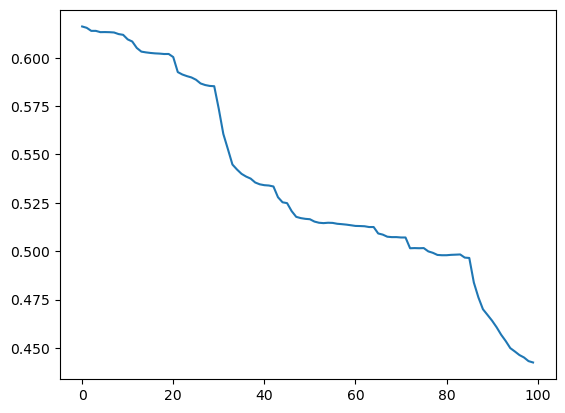

In [ ]:
import matplotlib.pyplot as plt    # tnpd  rmse
plt.plot(rmse)

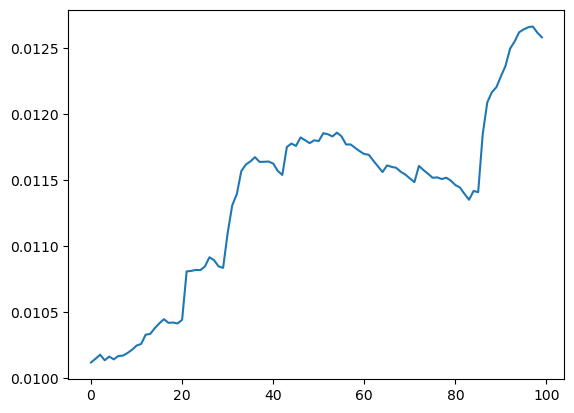

In [97]:
plt.plot(vars)

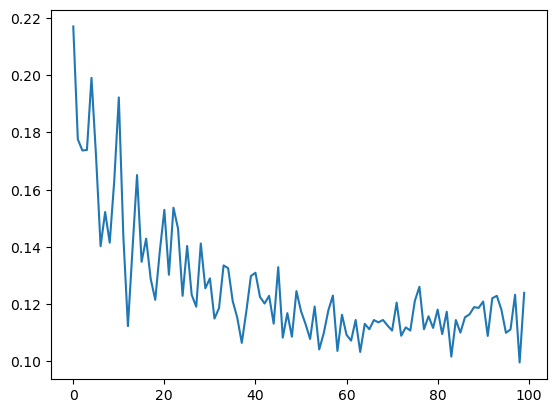

In [295]:
import matplotlib.pyplot as plt    # banp  rmse
plt.plot(rmse)

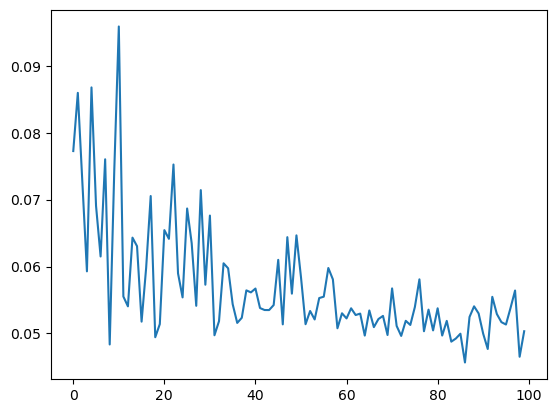

In [296]:
import matplotlib.pyplot as plt    # banp
plt.plot(vars)

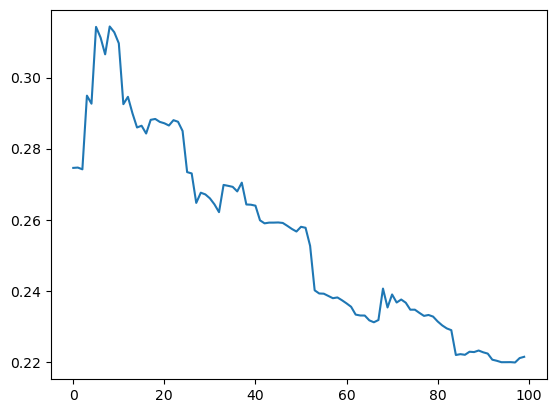

In [182]:
import matplotlib.pyplot as plt    # ConvCNP
plt.plot(vars)

In [26]:
def max_variance(task, n_placements=20, placement_strategy='max_variance'):
    task = copy.deepcopy(task)
    avg_std = []
    rmse_list = []

    for _ in range(n_placements + 1):
        model.eval()
        with torch.no_grad():
            prediction = model.predict(task.xc, task.yc, task.xt)

        avg_std.append(prediction.scale.mean().item()**2)

        rmse = mean_squared_error(
            task.yt.squeeze().cpu().numpy(),
            prediction.loc.squeeze().cpu().numpy(),
        )
        rmse_list.append(rmse)

        if placement_strategy == "random":
            idx = torch.randint(0, task.xt.shape[1], (1,))

        elif placement_strategy == "max_variance":
            _, idx = prediction.scale.max(dim=1)

        selected_xt = task.xt.squeeze(0)[idx.item()].unsqueeze(0)
        selected_yt = task.yt.squeeze(0)[idx.item()].unsqueeze(0)

        task.xc = torch.cat([task.xc.squeeze(0), selected_xt], dim=0).unsqueeze(0)
        task.yc = torch.cat([task.yc.squeeze(0), selected_yt], dim=0).unsqueeze(0)

        xt_new = torch.cat([
            task.xt.squeeze(0)[:idx.item()],
            task.xt.squeeze(0)[idx.item() + 1:]
        ], dim=0)
        yt_new = torch.cat([
            task.yt.squeeze(0)[:idx.item()],
            task.yt.squeeze(0)[idx.item() + 1:]
        ], dim=0)

        task.xt = xt_new.unsqueeze(0)
        task.yt = yt_new.unsqueeze(0)

    return avg_std[1:], rmse_list[1:]


In [27]:
stds, rmses = max_variance(task=test_sample, n_placements=100, placement_strategy='max_variance')
stds_r, rmses_r = max_variance(task=test_sample, n_placements=100, placement_strategy='random')

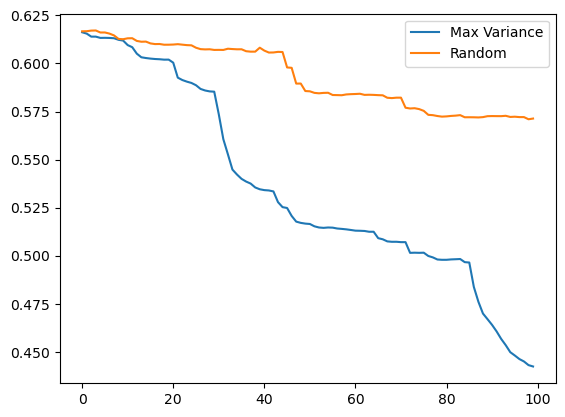

In [28]:
plt.plot(rmses)
plt.plot(rmses_r)
plt.legend(['Max Variance', 'Random'])
plt.show()

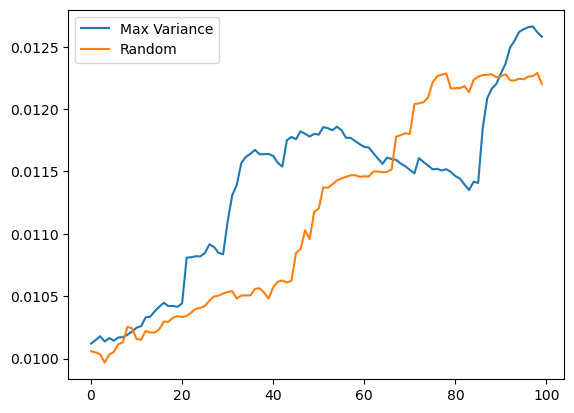

In [29]:
plt.plot(stds)
plt.plot(stds_r)
plt.legend(['Max Variance', 'Random'])
plt.show()